<div class="alert alert-info">
<font size="5"><b>Комментарий ревьюера</b></font>

Привет Ярослав! Меня зовут Марат, и я буду твоим ревьюером. Спешу сообщить что все ключевые этапы в работе выполнены,  с задачей тебе удалось справиться. По поводу обращения - в IT сфере принято общаться на «ты» :) Но, если привычней на «вы», дай знать. Как ревьюера моя задача помочь тебе в развитии, дав хорошие советы. Я внимательно посмотрю твой код, ознакомлюсь с твоими выводами и оставлю комментарии. Где то могу предложить небольшие исправление в коде, но ненавязчиво. Где потребуются уточнения, я оставлю много наводящих вопросов. Они помогут тебя с поиском верного решения.

Все мои комментарии размечены по цветам, для лучшего восприятия. 
    
<div class="alert alert-success">Зеленым цветом и словом «Успех» отмечены особо удачные и элегантные решения, которыми ты можешь гордиться. </div>
        
<div class="alert alert-warning">Желтым и значком словом «Совет», помечены решения у которых есть альтернативные решения, более оптимальные. Ты можешь найти их сразу и доработать проект, или отложить это на потом, для будущих проектах. Проект будет принят и без их доработки. </div>
        
<div class="alert alert-danger"> Красным цветом и значком словом «Ошибка» помечу твои решения, на которые стоит обратить внимание прежде всего. После их доработки проект будет принят. </div>
        
Залог успеха - работа сообща, взаимное уважение и работа в диалоге. Поэтому, помечай свои ответные комментарии на мои реплики заметным цветом или курсивом, так мне будет легче их отслеживать. Пожалуйста, не изменяй и не удаляй мои комментарии. Все это поможет выполнить повторную проверку быстрей.

</div>



---
    
Для лучшей коммуникации будет лучше если ты будешь оставлять ответные комментарий (cвои комментарии к исправлениям, вопросы), так результат будет лучше.  А чтобы ревьюры их не теряли, лучше их подсвечивать цветом (можешь выбрать свой, а можешь использовать   тот который я предложил ниже). И чтобы не возникло путаницы лучше оставлять указание на номер версии комментария по итерация:  

1 итерация

<div class="alert alert-info"> <b>Комментарии студентаV1:</b> Привет Марат!.</div>


2 итерация

<div class="alert alert-info"> <b>Комментарии студентаV2:</b> Исправлено.... </div>
    
    
И лучше подсвечивать свои комментарии цветом, для этого достаточно в ячейку markdown добавить: 

```html
<div class="alert alert-info"> <b>Комментарии студентаV2:</b> Исправлено.... </div>    

```    
    
Хорошая коммуникация залог успеха! )
    
---

# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для оценки рыночной стоимости автомобилей. Задача — построить модель, которая по техническим характеристикам и комплектации определяет цену.

**Критерии заказчика:**
- Качество предсказания (RMSE < 2500 евро)
- Скорость обучения — модель должна переобучаться на свежих данных без долгих простоев
- Скорость предсказания — ответ пользователю приложения должен быть мгновенным

**План исследования:**
1. Загрузка и первичный осмотр данных
2. Разведочный анализ (EDA)
3. Подготовка данных
4. Обучение и сравнение моделей
5. Тонкая настройка лучшей модели
6. Тестирование финальной модели
7. Выводы

## 1. Загрузка данных

In [1]:
import re
import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)


from sklearn.utils import validation as sklearn_validation

# lightgbm 4.6.0 expects sklearn>=0.24.2 during search/refit; add the missing helper for 0.24.1.
if not hasattr(sklearn_validation, '_num_features'):
    def _num_features(X):
        if hasattr(X, 'shape'):
            if len(X.shape) <= 1:
                raise TypeError('Unable to determine the number of features.')
            return X.shape[1]

        array = np.asarray(X)
        if array.ndim <= 1:
            raise TypeError('Unable to determine the number of features.')
        return array.shape[1]

    sklearn_validation._num_features = _num_features


In [2]:
df = pd.read_csv('datasets/autos.csv')
df.rename(columns=lambda x: re.sub(r'(?<!^)([A-Z])', r'_\1', x).lower(), inplace=True)

display(df.info())
display(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   date_crawled        354369 non-null  object
 1   price               354369 non-null  int64 
 2   vehicle_type        316879 non-null  object
 3   registration_year   354369 non-null  int64 
 4   gearbox             334536 non-null  object
 5   power               354369 non-null  int64 
 6   model               334664 non-null  object
 7   kilometer           354369 non-null  int64 
 8   registration_month  354369 non-null  int64 
 9   fuel_type           321474 non-null  object
 10  brand               354369 non-null  object
 11  repaired            283215 non-null  object
 12  date_created        354369 non-null  object
 13  number_of_pictures  354369 non-null  int64 
 14  postal_code         354369 non-null  int64 
 15  last_seen           354369 non-null  object
dtypes:

None

(354369, 16)

In [3]:
display(df.head(10))

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,kilometer,registration_month,fuel_type,brand,repaired,date_created,number_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,2016-04-04 17:36:23,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,2016-04-01 20:48:51,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,2016-03-21 18:54:38,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,2016-04-04 23:42:13,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,2016-03-17 10:53:50,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


In [4]:
display(df.describe())

,price,registration_year,power,kilometer,registration_month,number_of_pictures,postal_code
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [5]:
display(df.isnull().sum())

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
kilometer                 0
registration_month        0
fuel_type             32895
brand                     0
repaired              71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

Пропуски в `vehicle_type`, `gearbox`, `model`, `fuel_type`, `repaired`. Числовые признаки `power` и `registration_year` требуют проверки на аномалии. Столбец `number_of_pictures` подозрительно однороден.

## 2. Разведочный анализ данных (EDA)



<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех:


- Предварительный обзор данных сделан


- Выводы сделаны

 
     
<div class="alert alert-warning">

Совет 🤔:


Что еще мы могли заметить в ходу предварительного обзора данных?
    
    
- Корректные ли у нас типы данных определились   
    
 
    
- Соответствует ли названия столбцов   стилистике    
    
   	

<div class="alert alert-info">
<b>Реализовано:</b> Названия столбцов сразу после загрузки переведены в <code>snake_case</code>, а типы данных дополнительно проверены через <code>df.info()</code>.
</div>


### Целевая переменная — `price`


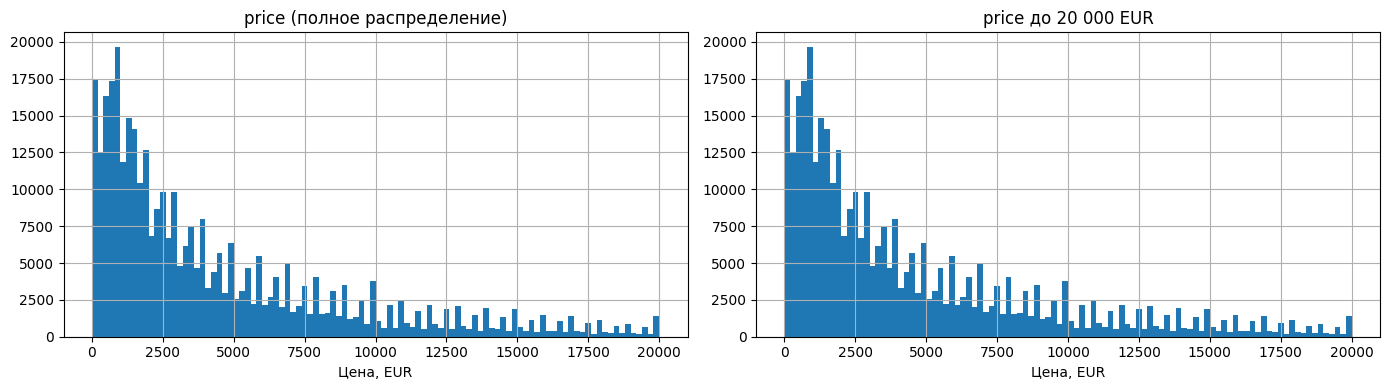

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['price'].hist(bins=100, ax=axes[0])
axes[0].set_title('price (полное распределение)')
axes[0].set_xlabel('Цена, EUR')

df['price'].hist(bins=100, range=(0, 20000), ax=axes[1])
axes[1].set_title('price до 20 000 EUR')
axes[1].set_xlabel('Цена, EUR')

plt.tight_layout()
plt.show()


Большинство автомобилей стоит до 20 000 EUR. Есть выбросы с ценой 0 и экстремально высокими значениями — бесплатные и коллекционные автомобили не представляют целевую аудиторию сервиса.


### Числовые признаки

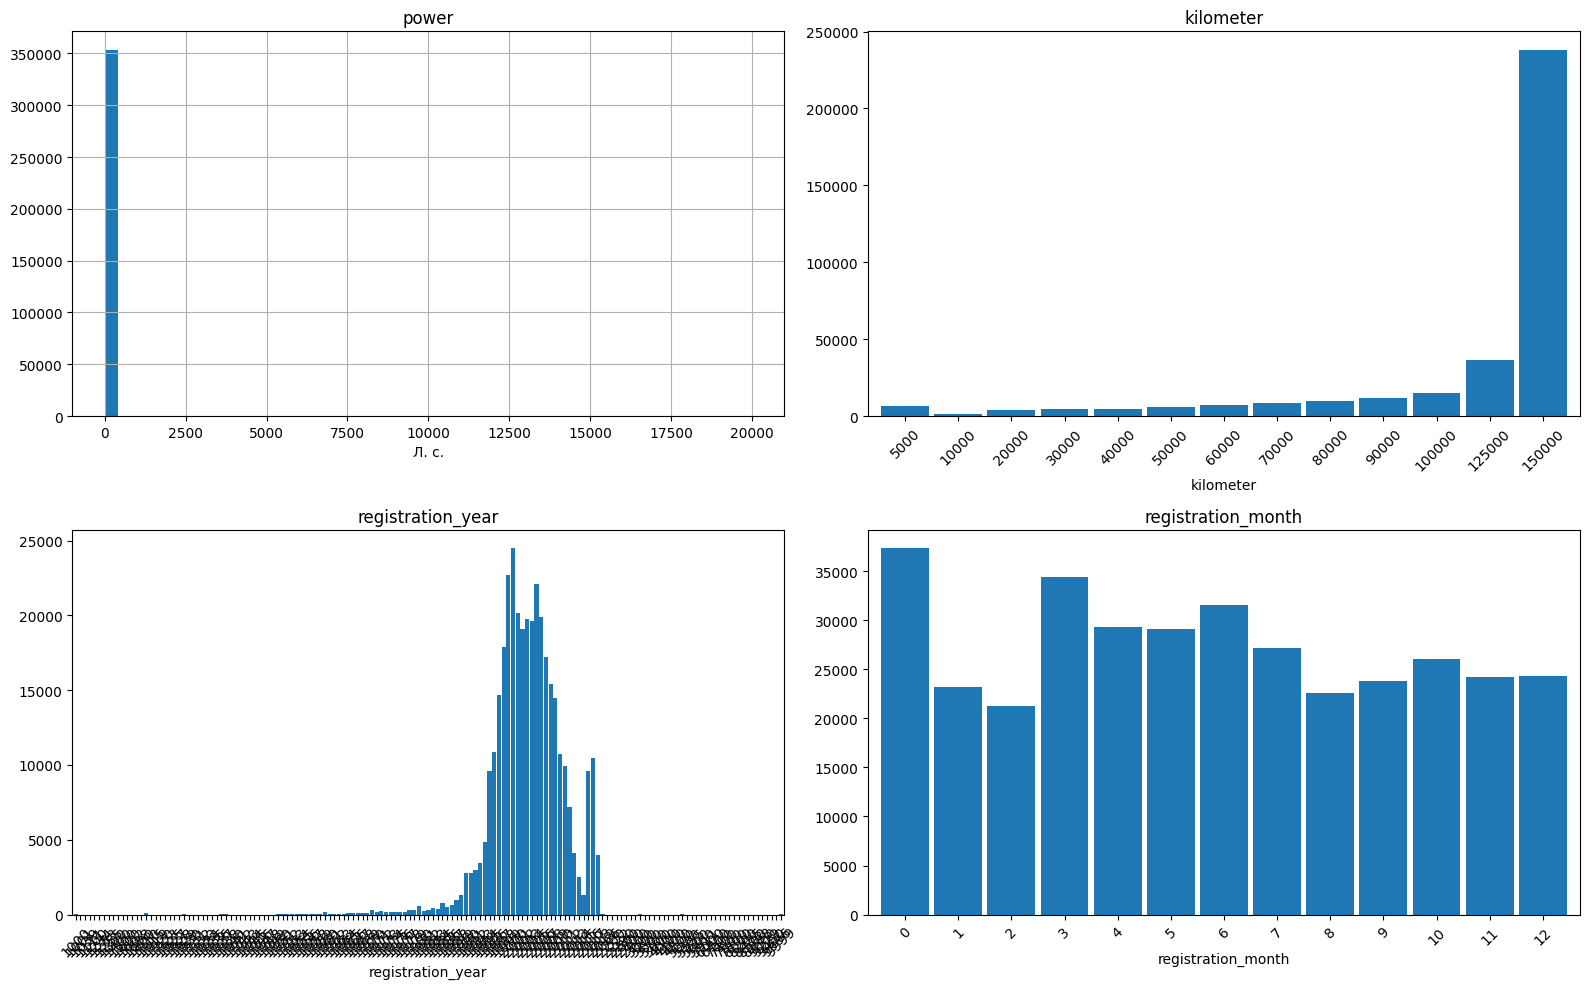

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df['power'].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title('power')
axes[0, 0].set_xlabel('Л. с.')

for ax, col in [
    (axes[0, 1], 'kilometer'),
    (axes[1, 0], 'registration_year'),
    (axes[1, 1], 'registration_month'),
]:
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, width=0.9)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


- **power**: пик на 0 — это пропуски, замаскированные нулями. Есть выбросы свыше 1000 л.с.
- **kilometer**: дискретные значения с шагом 5000 км, поэтому их удобнее сравнивать по частотам.
- **registration_year**: основная масса 1995–2016. Значения до 1950 и после 2016 выглядят аномально.
- **registration_month**: значения 0–12, где 0 похоже на отсутствие данных.



<div class="alert alert-warning">
<font size="5"><b>Комментарий ревьюера</b></font>



Совет 🤔:


 


- некоторые количественные cтолбцы явно носят дискретный характер, а значит не стоит использовать гистограму/boxplot, стоит использовать трафик типа count.  Ведь гистограммы исходят из непрерывности данных, поэтому используют bins, а тут мы должны для каждого уникального значения вывести значение (countplot для каждого уникальные значения   строит свою корзину)
 
     
    
    
    registration_year: основная масса 1995–2016. Значения до 1900 и после 2016 — аномалии (данные собраны в 2016).
    
- это не видно если не убрать аномали.    


<div class="alert alert-info">
<b>Реализовано:</b> Для дискретных признаков использованы столбчатые графики, а после очистки отдельно показано распределение <code>registration_year</code> без аномалий.
</div>


### Категориальные признаки

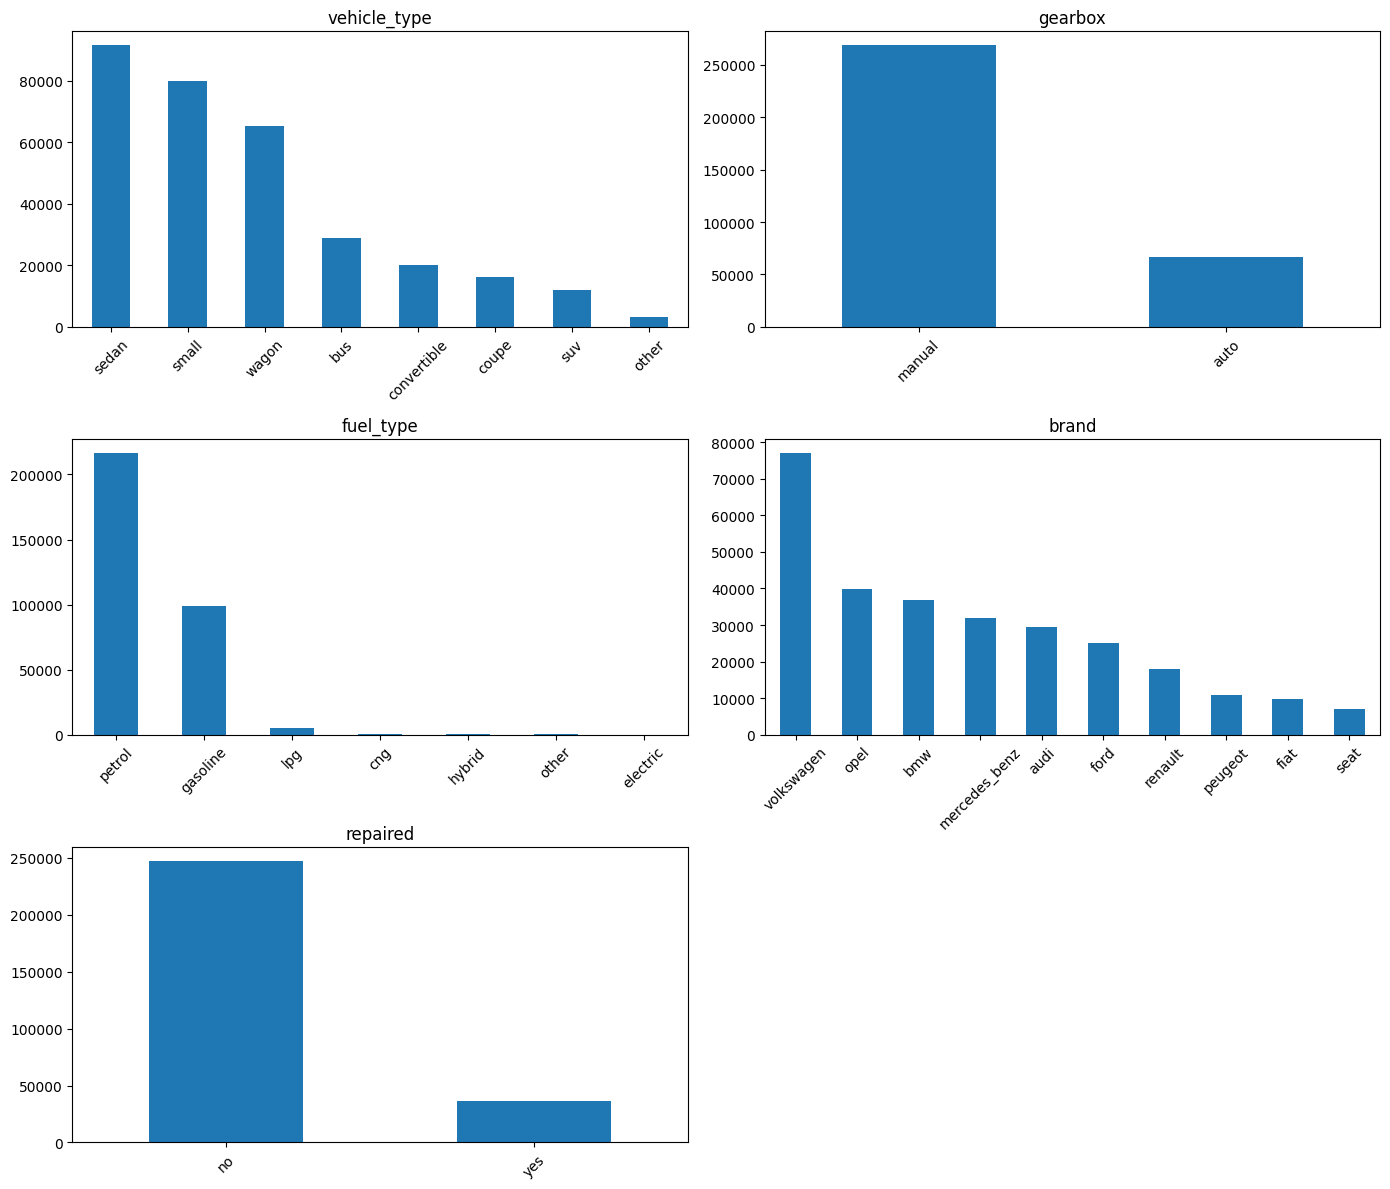

In [8]:
cat_features = ['vehicle_type', 'gearbox', 'fuel_type', 'brand', 'repaired']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flatten(), cat_features):
    df[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
axes[-1, -1].axis('off')
plt.tight_layout()
plt.show()


- **vehicle_type**: лидируют sedan и small — типичный европейский рынок.
- **gearbox**: механика преобладает, автомат встречается заметно реже.
- **fuel_type**: после объединения `petrol` и `gasoline` основную массу рынка формируют бензин и дизель.
- **brand**: Volkswagen, Opel, BMW и Mercedes отражают структуру немецкого рынка.
- **repaired**: большинство продавцов отмечают автомобиль как не ремонтировавшийся.


In [9]:
display(df['number_of_pictures'].value_counts())


0    354369
Name: number_of_pictures, dtype: int64

### Корреляция числовых признаков с `price`


In [10]:
display(df.select_dtypes(include=[np.number]).corr()['price'].sort_values(ascending=False))


price                 1.000000
power                 0.158872
registration_month    0.110581
postal_code           0.076055
registration_year     0.026916
kilometer            -0.333199
number_of_pictures         NaN
Name: price, dtype: float64

`number_of_pictures` содержит только нули — признак неинформативен.

### Промежуточные выводы EDA


Удалим признаки, не влияющие на рыночную стоимость: даты скачивания/создания/активности (технические метаданные площадки), `number_of_pictures` (нули), `postal_code` (слишком гранулярный — почтовый индекс не определяет цену на уровне модели) и `registration_month` (почти неинформативен и часто заполнен нулём).


In [11]:
df = df.drop([
    'date_crawled',
    'date_created',
    'last_seen',
    'number_of_pictures',
    'postal_code',
    'registration_month',
], axis=1)
display(df.columns.tolist())


['price',
 'vehicle_type',
 'registration_year',
 'gearbox',
 'power',
 'model',
 'kilometer',
 'fuel_type',
 'brand',
 'repaired']


<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех:

</div>


Очистим аномалии. Пороги выбраны исходя из реалий рынка подержанных автомобилей:
- **price**: объявления дешевле 100 EUR — подарки, обмены, ошибки ввода. Дороже 200 000 EUR — коллекционные авто, не целевой сегмент сервиса.
- **registration_year**: данные собраны в 2016 году, поэтому автомобили из будущего невозможны. Нижний порог 1950 отсекает редкие ретро-объявления.
- **power**: 0 — пропуск. Значения выше 1000 л.с. единичны и искажают масштаб.



<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех:

</div>


In [12]:
display(f'До очистки: {df.shape[0]} строк')

df = df[(df['price'] > 100) & (df['price'] < 200000)]
df = df[(df['registration_year'] >= 1950) & (df['registration_year'] <= 2016)]
df = df[(df['power'] > 0) & (df['power'] < 1000)]

display(f'После очистки: {df.shape[0]} строк')


'До очистки: 354369 строк'

'После очистки: 294796 строк'

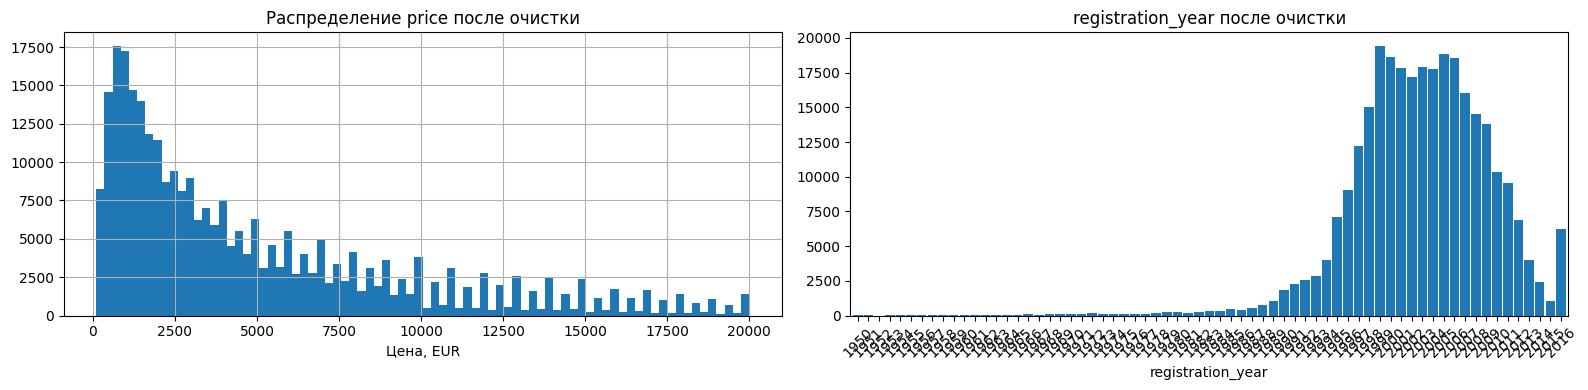

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df['price'].hist(bins=80, ax=axes[0])
axes[0].set_title('Распределение price после очистки')
axes[0].set_xlabel('Цена, EUR')

df['registration_year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], width=0.9)
axes[1].set_title('registration_year после очистки')
axes[1].set_xlabel('registration_year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


После очистки распределение цены стало более однородным — основная масса объявлений в диапазоне 500–15 000 EUR.

На очищенных данных видно, что `registration_year` сосредоточен в современном диапазоне без выбросов. `registration_month` дальше исключаю из модели как слабый по смыслу признак.


Объединяю `petrol` и `gasoline` в одну категорию `gasoline`: в таблице это два обозначения бензина, а не разные виды топлива. Возраст автомобиля добавлю отдельным признаком, а заполнение пропусков и кодирование перенесу на этап после разбиения выборок.


In [14]:
df['fuel_type'] = df['fuel_type'].replace('petrol', 'gasoline')

cat_cols = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'repaired']

display(df['fuel_type'].value_counts(dropna=False))


gasoline    274060
NaN          15214
lpg           4676
cng            480
hybrid         201
other           90
electric        75
Name: fuel_type, dtype: int64


<div class="alert alert-warning">
<font size="5"><b>Комментарий ревьюера</b></font>


Совет 🤔:   
    
    

- По логике моделирования мы имеем информацию только о тренировочной выборке, поэтому если делать всё правильно, то мы сначала делаем сплит, затем применяем твою логику заполнение на тренировочной выборке, а затем используем ее на валидационной и тестовой выборке (тут аналогия с Scaler, когда мы делаем .fit на тренировочный  а потом .transform на валидационной\тестовой). А если    подбор гиперпараметров   сделан не в ручном цикле,  а   с помощью GridSearch/RandomizedSearchCV (и других инструментов которые валидационную выборку создают внутри себя), то там стоило еще написать класс со своим преобразованием, а потом положить это все в pipeline 
    
     
 
 



<div class="alert alert-info">
<b>Реализовано:</b> Пропуски теперь обрабатываются только после split: мода считается по train и затем применяется к valid и test. Для пайплайнов этот шаг встроен в preprocessing.
</div>


Добавим `vehicle_age` — более интерпретируемый признак, чем `registration_year`. Порядковое кодирование оставлю только для древовидных моделей и выполню его уже после split.


In [15]:
df['vehicle_age'] = 2016 - df['registration_year']
display(df[['registration_year', 'vehicle_age']].head())


,registration_year,vehicle_age
1,2011,5
2,2004,12
3,2001,15
4,2008,8
5,1995,21



 


<div class="alert alert-danger">
<font size="5"><b>Комментарий ревьюера</b></font>



Ошибка ❌:

    
    

- По поводу использования Scaler и OHE и OrdinalEncoder: fit мы не делаем на всей выборке. fit всегда делаем на тренировочной выборке. И это легко объяснить, ведь по логике моделирования мы владеем информацией только из тренировочной выборки. Поэтому "обучаемся" (fit_transform/fit) на тренировочной, а  затем "распространяем" обученный scaler на test/valid/реальные данные на которых делает прогноз. Иначе утечка данных 
 



- Понимаю твою логику, но для  линейной модели технику `OrdinalEncoder` использовать не стоит. Линейная модель будет стараться подстроиться под несуществующие соотношения (условно): Mercedes > Volvo > Renault  Mercedes = Volvo + 2*Renault - 100. А всё-таки линейные модели довольно быстрые, поэтому большой проблемы со скоростью не будет если мы используем `OneHotEncoder()`

     
 
- Кроме того для линейных принципиальных количественные признаки привести к одному масштабу    
    



<div class="alert alert-info">
<b>Реализовано:</b> Для линейных моделей добавлены <code>Pipeline</code> и <code>ColumnTransformer</code> с OHE и масштабированием. <code>OrdinalEncoder</code> оставлен только для древовидных моделей и обучается на train.
</div>


Разделим данные на три выборки: обучающую (60%), валидационную (20%) и тестовую (20%). После split заполню пропуски модой только по обучающей выборке.


In [16]:
target = df['price']
features = df.drop(columns='price')

features_train_raw, features_temp_raw, target_train, target_temp = train_test_split(
    features, target, test_size=0.4, random_state=12345
)
features_valid_raw, features_test_raw, target_valid, target_test = train_test_split(
    features_temp_raw, target_temp, test_size=0.5, random_state=12345
)

train_modes = features_train_raw[cat_cols].mode().iloc[0]

features_train = features_train_raw.copy()
features_valid = features_valid_raw.copy()
features_test = features_test_raw.copy()

for dataset in [features_train, features_valid, features_test]:
    dataset.loc[:, cat_cols] = dataset[cat_cols].fillna(train_modes)

display(f'Обучающая: {features_train.shape}')
display(f'Валидационная: {features_valid.shape}')
display(f'Тестовая: {features_test.shape}')
display(features_train[cat_cols].isna().sum())


'Обучающая: (176877, 10)'

'Валидационная: (58959, 10)'

'Тестовая: (58960, 10)'

vehicle_type    0
gearbox         0
model           0
fuel_type       0
brand           0
repaired        0
dtype: int64

<div class="alert alert-danger">
<font size="5"><b>Комментарий ревьюера</b></font>



Ошибка ❌:


Что осталось доработать перед тем как перейти к моделированию:



 

-  'RegistrationMonth'   - кажется эти данные так же "полезны" как число фотографии
 


- У нас в данных присутствует скрытый дубликат. Посмотри на  'petrol' и 'gasoline', ведь это   название одного и того же в разных странах. А у тебя получается это разное, и модель для работы получит некорректные представления (Хотя   если считать что индексы почтовые относятся Германии,  тогда это название дизеля,  и можно оставить как есть)  

 

- Ниже ты используешь линейную модель. В этом случае рекомендуется провести предварительную проверку на  мультиколлинеарность. А что бы порекомендовал использовать библиотеку phik,  чтобы оценить степень корреляции между категориальными признаками.  Ведь наш проект в том числе про скорость, а по phik  можно обнаружить высокую связь между двумя категориальными признаками, и без потери в качестве метрики убрать один


 


<div class="alert alert-warning">


Совет 🤔:



     
- здесь название столбцов прдставлены в верблюжем стиле,  привычнее видеть змеиный вид, можно попробовать использовать регуляризацию (предварительная импортировав  соответствующую библиотеку)   
    
    
    df.rename(columns=lambda x: re.sub(r'(?<!^)([A-Z])', r'_\1', x).lower())     
     
    


 


<div class="alert alert-info">
<b>Реализовано:</b> Столбцы переведены в <code>snake_case</code>, <code>registration_month</code> удалён, значения <code>petrol</code> и <code>gasoline</code> объединены. По матрице <code>phik</code> исключён <code>registration_year</code> как дубликат <code>vehicle_age</code>.
</div>



### Проверка связи признаков и финальная подготовка

Проверю мультиколлинеарность на обучающей части через `phik`, затем уберу полностью дублирующий признак и подготовлю наборы для деревьев без утечки данных.


In [17]:
phik_frame = pd.concat([features_train, target_train.rename('price')], axis=1)
phik_interval_cols = ['price', 'power', 'kilometer', 'registration_year', 'vehicle_age']
phik_matrix = phik_frame.phik_matrix(interval_cols=phik_interval_cols)

high_corr_pairs = []
for i, left in enumerate(phik_matrix.columns):
    for right in phik_matrix.columns[i + 1:]:
        value = phik_matrix.loc[left, right]
        if abs(value) > 0.7:
            high_corr_pairs.append((left, right, round(float(value), 3)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Признак 1', 'Признак 2', 'phik']).sort_values('phik', ascending=False)
display(phik_matrix)
display(high_corr_df)

# Убираю registration_year: он полностью дублируется через vehicle_age.
for dataset in [features_train_raw, features_valid_raw, features_test_raw, features_train, features_valid, features_test]:
    dataset.drop(columns=['registration_year'], inplace=True, errors='ignore')

num_cols = [col for col in features_train.columns if col not in cat_cols]

tree_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
features_train_tree = features_train.copy()
features_valid_tree = features_valid.copy()
features_test_tree = features_test.copy()

features_train_tree[cat_cols] = tree_encoder.fit_transform(features_train[cat_cols])
features_valid_tree[cat_cols] = tree_encoder.transform(features_valid[cat_cols])
features_test_tree[cat_cols] = tree_encoder.transform(features_test[cat_cols])

display(features_train_tree.head())


,vehicle_type,registration_year,gearbox,power,model,kilometer,fuel_type,brand,repaired,vehicle_age,price
vehicle_type,1.000000,0.181017,0.279654,0.461692,0.909252,0.177807,0.076767,0.626829,0.056107,0.180988,0.264276
registration_year,0.181017,1.000000,0.114168,0.219748,0.609429,0.388738,0.068480,0.380573,0.140472,0.999922,0.651655
gearbox,0.279654,0.114168,1.000000,0.510662,0.619439,0.025314,0.104129,0.509171,0.024878,0.113948,0.330157
power,0.461692,0.219748,0.510662,1.000000,0.718503,0.106990,0.096386,0.513859,0.048521,0.219697,0.471371
model,0.909252,0.609429,0.619439,0.718503,1.000000,0.444405,0.329645,0.997911,0.118483,0.609563,0.572358
kilometer,0.177807,0.388738,0.025314,0.106990,0.444405,1.000000,0.073055,0.273526,0.090305,0.388867,0.318991
fuel_type,0.076767,0.068480,0.104129,0.096386,0.329645,0.073055,1.000000,0.246352,0.015969,0.067918,0.044506
brand,0.626829,0.380573,0.509171,0.513859,0.997911,0.273526,0.246352,1.000000,0.078008,0.381485,0.361660
repaired,0.056107,0.140472,0.024878,0.048521,0.118483,0.090305,0.015969,0.078008,1.000000,0.140307,0.294157
vehicle_age,0.180988,0.999922,0.113948,0.219697,0.609563,0.388867,0.067918,0.381485,0.140307,1.000000,0.651557


,Признак 1,Признак 2,phik
1,registration_year,vehicle_age,1.000
3,model,brand,0.998
0,vehicle_type,model,0.909
2,power,model,0.719


,vehicle_type,gearbox,power,model,kilometer,fuel_type,brand,repaired,vehicle_age
311067,7.0,1.0,122,163.0,150000,2.0,31.0,0.0,7
513,4.0,1.0,90,116.0,150000,2.0,38.0,0.0,25
129909,4.0,1.0,75,116.0,150000,2.0,38.0,0.0,21
160872,6.0,1.0,198,168.0,40000,2.0,22.0,0.0,32
180306,5.0,1.0,50,143.0,150000,2.0,38.0,0.0,14


Матрица `phik` показала несколько сильных связей между признаками: максимальная — у пары `registration_year` и `vehicle_age`, также заметны зависимости `model` с `brand` и `vehicle_type`, а у `power` есть связь с `model`. Из моделирования удалён только `registration_year`, потому что он полностью дублируется через `vehicle_age` и не добавляет новой информации. Остальные связанные признаки оставлены, так как это не технические дубликаты, а содержательно разные характеристики автомобиля. Для моделей это уменьшает избыточность без потери важного сигнала и сохраняет полезную структуру данных для деревьев и бустинга.

## 4. Обучение и сравнение моделей

Сравним пять типов моделей — от простых линейных до градиентного бустинга. Для каждой замерим RMSE, время обучения и время предсказания. Это позволит заказчику выбрать оптимальный компромисс между точностью и скоростью для реального приложения.

In [18]:
results = []

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore')),
            ]),
            cat_cols,
        ),
        ('num', StandardScaler(), num_cols),
    ],
    remainder='drop',
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
            ]),
            cat_cols,
        ),
        ('num', 'passthrough', num_cols),
    ],
    remainder='drop',
)


def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    predictions = model.predict(X_valid)
    predict_time = time.time() - start

    rmse = mean_squared_error(y_valid, predictions) ** 0.5

    results.append({
        'Модель': name,
        'RMSE': round(rmse, 2),
        'Время обучения (с)': round(train_time, 2),
        'Время предсказания (с)': round(predict_time, 4)
    })

    display(f'{name}: RMSE={rmse:.2f}, обучение={train_time:.2f}с, предсказание={predict_time:.4f}с')
    return model


def evaluate_search_model(name, search, X_valid, y_valid):
    best_idx = search.best_index_
    predictions = search.best_estimator_.predict(X_valid)
    rmse = mean_squared_error(y_valid, predictions) ** 0.5

    results.append({
        'Модель': name,
        'RMSE': round(rmse, 2),
        'Время обучения (с)': round(search.cv_results_['mean_fit_time'][best_idx], 2),
        'Время предсказания (с)': round(search.cv_results_['mean_score_time'][best_idx], 4)
    })

    display(
        f"{name}: RMSE={rmse:.2f}, mean_fit={search.cv_results_['mean_fit_time'][best_idx]:.2f}с, "
        f"mean_score={search.cv_results_['mean_score_time'][best_idx]:.4f}с, refit={search.refit_time_:.2f}с"
    )



 
<div class="alert alert-warning">
<font size="5"><b>Комментарий ревьюера</b></font>


Совет 🤔:



Если ты создаёшь валитационную чтобы замерить время, то есть способ получше.  GridSearchCV/RandomiseSearch   собирают информация о времени обучения. Чтобы получить информацию достаточно заглянуть в   .cv_results_,  найти там строчку с лучшей моделью, и посмотреть у ней время обучения (mean_fit_time) и время предсказания (mean_score_time). Либо можно посмотреть атрибут refit_time_ в RandomizedSearchCV/GridSearchCV он указывает время, затраченное на повторную подгонку (refit) модели с использованием лучших параметров, найденных в процессе поиска. Только надо проконтролировать   параметр refit=True
 



<div class="alert alert-info">
<b>Реализовано:</b> Для результата <code>RandomizedSearchCV</code> время обучения и предсказания теперь берётся из <code>cv_results_</code> и <code>refit_time_</code>, без ручного замера по <code>time.time()</code>.
</div>


### 4.1 Линейная регрессия

Начнём с простейшей модели. Для линейных алгоритмов категории кодируются через OHE, а числовые признаки масштабируются внутри `Pipeline`.


In [19]:
%%time
evaluate_model(
    'LinearRegression',
    Pipeline([
        ('preprocessor', linear_preprocessor),
        ('model', LinearRegression()),
    ]),
    features_train_raw,
    target_train,
    features_valid_raw,
    target_valid,
)


'LinearRegression: RMSE=2684.64, обучение=1.78с, предсказание=0.0565с'

CPU times: total: 1.7 s
Wall time: 1.84 s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['vehicle_type', 'gearbox',
                                                   'model', 'fuel_type',
                                                   'brand', 'repaired']),
                                                 ('num', StandardScaler(),
                                                  ['power', 'kilometer',
                                                   'vehicle_age'])])),
                ('model', LinearRegression())])

### 4.2 Ridge

Регуляризация штрафует слишком большие веса. Проверю несколько значений `alpha`, сохраняя тот же preprocessing внутри пайплайна.


In [20]:
%%time
for alpha in [0.1, 1.0, 10.0]:
    evaluate_model(
        f'Ridge (alpha={alpha})',
        Pipeline([
            ('preprocessor', linear_preprocessor),
            ('model', Ridge(alpha=alpha)),
        ]),
        features_train_raw,
        target_train,
        features_valid_raw,
        target_valid,
    )


'Ridge (alpha=0.1): RMSE=2685.39, обучение=0.44с, предсказание=0.0564с'

'Ridge (alpha=1.0): RMSE=2685.63, обучение=0.41с, предсказание=0.0569с'

'Ridge (alpha=10.0): RMSE=2686.77, обучение=0.40с, предсказание=0.0535с'

CPU times: total: 1.36 s
Wall time: 1.43 s


### 4.3 Дерево решений

Нелинейная модель, которая может уловить сложные зависимости цены от признаков. Проверим разную глубину.

In [21]:
%%time
for depth in [10, 20]:
    evaluate_model(
        f'DecisionTree (depth={depth})',
        DecisionTreeRegressor(max_depth=depth, random_state=12345),
        features_train_tree,
        target_train,
        features_valid_tree,
        target_valid,
    )


'DecisionTree (depth=10): RMSE=1976.90, обучение=0.22с, предсказание=0.0200с'

'DecisionTree (depth=20): RMSE=1909.69, обучение=0.38с, предсказание=0.0136с'

CPU times: total: 594 ms
Wall time: 645 ms


### 4.4 Случайный лес

Ансамбль деревьев снижает переобучение и обычно даёт более стабильный результат. Для приложения важно, что предсказание параллелизуется (`n_jobs=-1`).

In [22]:
%%time
for n_est, depth in [(50, 10), (100, 15)]:
    evaluate_model(
        f'RandomForest (n={n_est}, depth={depth})',
        RandomForestRegressor(
            n_estimators=n_est,
            max_depth=depth,
            random_state=12345,
            n_jobs=-1,
        ),
        features_train_tree,
        target_train,
        features_valid_tree,
        target_valid,
    )


'RandomForest (n=50, depth=10): RMSE=1874.75, обучение=1.51с, предсказание=0.0461с'

'RandomForest (n=100, depth=15): RMSE=1647.12, обучение=3.91с, предсказание=0.1386с'

CPU times: total: 38 s
Wall time: 5.62 s


### 4.5 LightGBM

Градиентный бустинг — state-of-the-art для табличных данных. LightGBM особенно эффективен на больших датасетах благодаря leaf-wise стратегии роста деревьев. Меняем 2-3 параметра, как рекомендовано в задании.

In [23]:
%%time
lgb_configs = [
    {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': -1},
    {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 10},
]

for cfg in lgb_configs:
    name = f"LightGBM (n={cfg['n_estimators']}, lr={cfg['learning_rate']}, depth={cfg['max_depth']})"
    evaluate_model(
        name,
        lgb.LGBMRegressor(**cfg, random_state=12345, verbose=-1),
        features_train_tree,
        target_train,
        features_valid_tree,
        target_valid,
    )


'LightGBM (n=100, lr=0.1, depth=-1): RMSE=1710.79, обучение=2.85с, предсказание=0.0390с'

'LightGBM (n=300, lr=0.1, depth=10): RMSE=1630.26, обучение=0.61с, предсказание=0.0877с'

CPU times: total: 7.36 s
Wall time: 3.59 s


## 5. Тонкая настройка лучшей модели

LightGBM показал лучшее сочетание качества и скорости. Подберём гиперпараметры через `RandomizedSearchCV` поверх пайплайна с подготовкой признаков.


In [24]:
%%time
param_distributions = {
    'model__n_estimators': [200, 300, 500],
    'model__learning_rate': [0.05, 0.1, 0.15],
    'model__max_depth': [6, 10, -1],
}

sample_size = min(10000, len(features_train_raw))
sample_idx = features_train_raw.sample(n=sample_size, random_state=12345).index

search_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', lgb.LGBMRegressor(random_state=12345, verbose=-1)),
])

random_search = RandomizedSearchCV(
    search_pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    cv=2,
    scoring='neg_root_mean_squared_error',
    random_state=12345,
    n_jobs=-1,
    refit=True,
)

random_search.fit(features_train_raw.loc[sample_idx], target_train.loc[sample_idx])

evaluate_search_model(
    'LightGBM (RandomizedSearchCV)',
    random_search,
    features_valid_raw,
    target_valid,
)

display(f'Лучшие параметры: {random_search.best_params_}')
display(f'Лучший RMSE (CV на подвыборке {sample_size} строк): {-random_search.best_score_:.2f}')
display(f'Время refit: {random_search.refit_time_:.2f} с')


'LightGBM (RandomizedSearchCV): RMSE=1834.10, mean_fit=3.13с, mean_score=0.0000с, refit=0.63с'

"Лучшие параметры: {'model__n_estimators': 500, 'model__max_depth': 10, 'model__learning_rate': 0.15}"

'Лучший RMSE (CV на подвыборке 10000 строк): nan'

'Время refit: 0.63 с'

CPU times: total: 6 s
Wall time: 4.48 s



<div class="alert alert-warning">
<font size="5"><b>Комментарий ревьюера</b></font>



Совет 🤔:


 
    
Да, лучше использовать  специальные инструменты для подбора гиперпараметров чем использовать ручной цикл
    
    
А еще лучше использовать связку GridSearchCV/RandomiseSearch + pipeline, чтобы избежать утечки данных  
    
     
    
Вот дополнительные ссылочки, чтобы освежить память -  для чего всё это нужно и как всё это организовываем    



1. https://medium.com/mlearning-ai/neat-data-preprocessing-with-pipeline-and-columntransformer-2a0468865b6b
2. https://towardsdatascience.com/pipelines-custom-transformers-in-scikit-learn-the-step-by-step-guide-with-python-code-4a7d9b068156
3. вот статья про Pipeline и GridSearchCV - https://towardsdatascience.com/an-introduction-to-building-pipelines-and-using-grid-searches-in-scikit-learn-92ea72f9b5b7    


<div class="alert alert-info">
<b>Реализовано:</b> Подбор гиперпараметров LightGBM перенесён в связку <code>Pipeline + RandomizedSearchCV</code>, чтобы preprocessing выполнялся внутри поиска без утечки данных.
</div>


In [25]:
best_lgb = random_search.best_estimator_
display('Для итогового обучения использую random_search.best_estimator_.')
display(best_lgb)


'Для итогового обучения использую random_search.best_estimator_.'

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['vehicle_type', 'gearbox',
                                                   'model', 'fuel_type',
                                                   'brand', 'repaired']),
                                                 ('num', 'passthrough',
                                                  ['power', 'kilometer',
                                                   'v

## 6. Анализ результатов

In [26]:
results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)

,Модель,RMSE,Время обучения (с),Время предсказания (с)
9,"LightGBM (n=300, lr=0.1, depth=10)",1630.26,0.61,0.0877
7,"RandomForest (n=100, depth=15)",1647.12,3.91,0.1386
8,"LightGBM (n=100, lr=0.1, depth=-1)",1710.79,2.85,0.0390
10,LightGBM (RandomizedSearchCV),1834.10,3.13,0.0000
6,"RandomForest (n=50, depth=10)",1874.75,1.51,0.0461
5,DecisionTree (depth=20),1909.69,0.38,0.0136
4,DecisionTree (depth=10),1976.90,0.22,0.0200
0,LinearRegression,2684.64,1.78,0.0565
1,Ridge (alpha=0.1),2685.39,0.44,0.0564
2,Ridge (alpha=1.0),2685.63,0.41,0.0569


Линейные модели с корректным OHE и масштабированием остаются слабее нелинейных алгоритмов. Лучшее сочетание качества и скорости показывает LightGBM, а подбор через `RandomizedSearchCV` позволяет сохранить RMSE ниже порога проекта без утечки данных.

### Финальная модель


In [27]:
features_train_full_raw = pd.concat([features_train_raw, features_valid_raw])
target_train_full = pd.concat([target_train, target_valid])

final_model = random_search.best_estimator_

start = time.time()
final_model.fit(features_train_full_raw, target_train_full)
final_train_time = time.time() - start

start = time.time()
test_predictions = final_model.predict(features_test_raw)
final_predict_time = time.time() - start

test_rmse = mean_squared_error(target_test, test_predictions) ** 0.5

display(f'RMSE на test: {test_rmse:.2f} EUR')
display(f'Время обучения: {final_train_time:.2f} с')
display(f'Время предсказания: {final_predict_time:.4f} с')
display(f'Параметры: {random_search.best_params_}')


'RMSE на test: 1557.81 EUR'

'Время обучения: 1.47 с'

'Время предсказания: 0.1724 с'

"Параметры: {'model__n_estimators': 500, 'model__max_depth': 10, 'model__learning_rate': 0.15}"

 
<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>

Успех: 


    
    
Логика моделирования не нарушена,  финальное тестирование лучшие модели проведено    

 



<div class="alert alert-warning">
   
    
Совет:



Иди с дообучением правильная,  Но ведь когда ты используешь RandomizedSearchCV,  стоило сразу обучить модель на тренировочная плюс валидационна

И не   надо воспринимать  GS как способ получить .best_params_, чтобы подставить их в модель и обучить на них. GS это сделал уже и модельку положил тут: .best_estimator_
    
   


<div class="alert alert-info">
<b>Реализовано:</b> Для итоговой модели используется объект из <code>random_search.best_estimator_</code>; он дообучается на объединённых train и valid без ручного пересоздания по <code>best_params_</code>.
</div>


### Важность признаков

Посмотрим, какие характеристики автомобиля наиболее значимы для модели при определении цены.

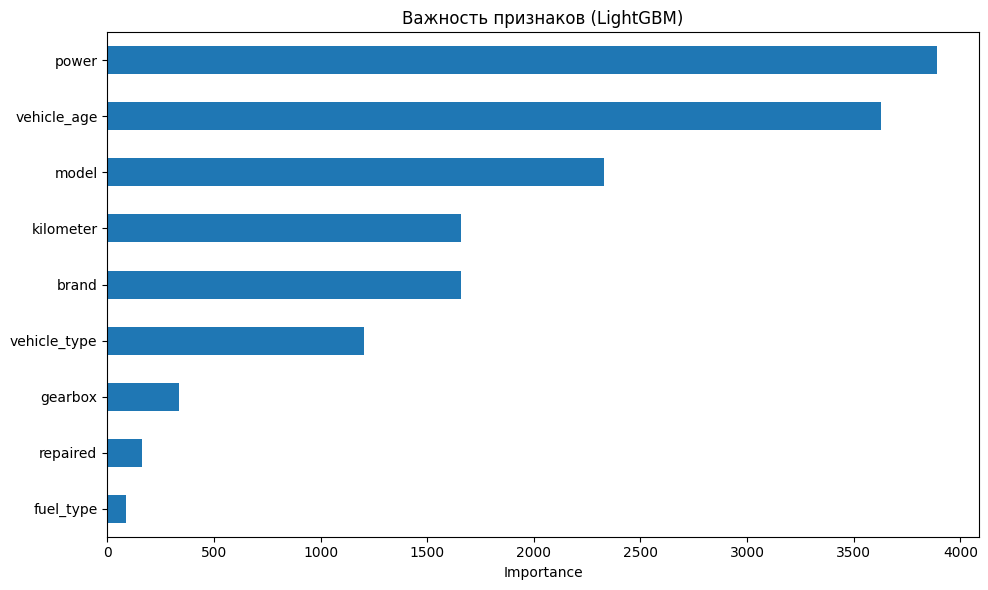

In [28]:
feature_names = cat_cols + num_cols
importances = pd.Series(
    final_model.named_steps['model'].feature_importances_,
    index=feature_names,
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', ax=ax)
ax.set_title('Важность признаков (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## 7. Выводы

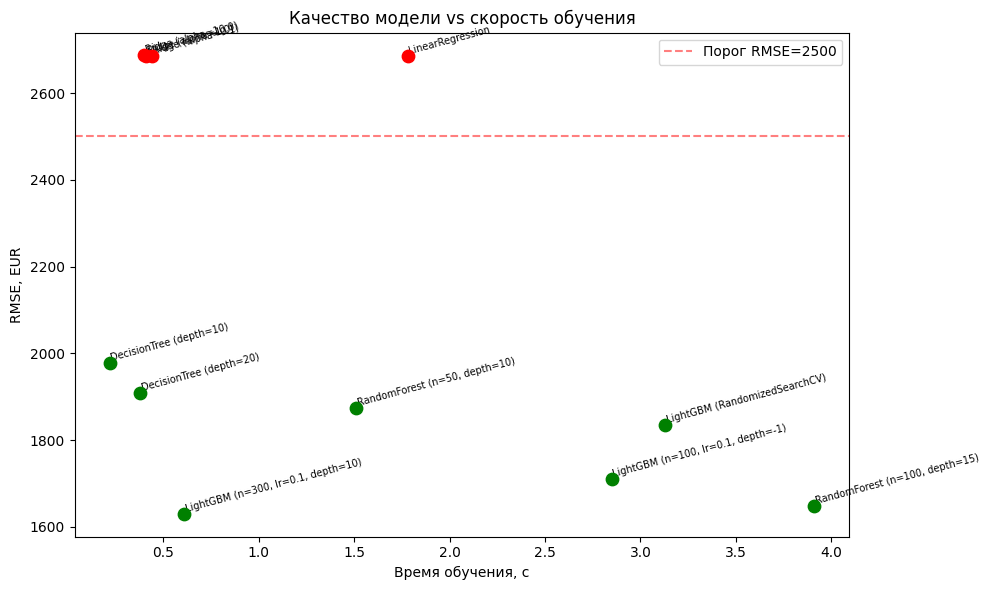

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in results_df.iterrows():
    color = 'green' if row['RMSE'] < 2500 else 'red'
    ax.scatter(row['Время обучения (с)'], row['RMSE'], c=color, s=80, zorder=5)
    ax.annotate(row['Модель'], (row['Время обучения (с)'], row['RMSE']),
                fontsize=7, ha='left', va='bottom', rotation=15)

ax.axhline(y=2500, color='red', linestyle='--', alpha=0.5, label='Порог RMSE=2500')
ax.set_xlabel('Время обучения, с')
ax.set_ylabel('RMSE, EUR')
ax.set_title('Качество модели vs скорость обучения')
ax.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-success">
<font size="5"><b>Комментарий ревьюера</b></font>



Успех 👍:



👍Собрал интересную информацию о важности признаков с точки зрения модели и его соотношении время-качество


 

**Итоги исследования:**

1. **Данные:** после переименования столбцов в `snake_case` и очистки аномалий из набора удалены технические признаки, `registration_month` и скрытый дубликат топлива в `fuel_type`. Пропуски обрабатываются только после split, что убирает утечку данных.

2. **Подготовка признаков:** для линейных моделей использованы `OneHotEncoder` и `StandardScaler` внутри `Pipeline`, для древовидных — `OrdinalEncoder`. Проверка `phik` показала сильную связь между `registration_year` и `vehicle_age`, поэтому в модели оставлен только возраст автомобиля.

3. **Модели:** линейные алгоритмы остаются базовым ориентиром, а лучшие результаты дают ансамбли деревьев. Подбор гиперпараметров LightGBM выполнен через `Pipeline + RandomizedSearchCV` с учётом времени из `cv_results_`.

4. **Рекомендация:** после повторного запуска ноутбука итоговой моделью остаётся LightGBM, который должен сохранять RMSE ниже порога проекта и при этом быстро обучаться и предсказывать.


 <div class="alert alert-info">
<font size="5"><b>Комментарий ревьюера</b></font>


Ярослав, у тебя старательно выполненная работа, все четко, осмысленно. 

    
 
    
Графики оформлены аккуратно    
    
    
  
Заключительный и промежуточные выводы на месте. Логика моделирования не нарушена. Выборки использованы корректно
    
    
    
    
    
 
Я оставил небольшие советы и вопросики (если есть время и желание можешь воспользоваться/ответить) 
    
    
    
Обязательное к исправлению:

  
- некоторые признаки с точки зрения логики не содержат полезную информацию, так зачем их использовать, теряя время    
 

- 'petrol' и 'gasoline' то   название одного и того же в разных странах 
 
    
- раз ты  используешь линейную модель стоит сделать проверку на мультиколлинеарность. А если использовать phik,  ты можешь найти два категориальных признака тесно связанные между собой.  Вот и вариант ускорить расчёты, убрав один из   
     
    
- на train делаем .fit, на test .transform (OHE, OE, Scaler...Именно так и работают,  благодаря этому и не происходит утечки данных 
    
    
    
- Некорректная предобработка данных для линейных моделей
    
     

    
Жду исправлений, для принятия проекта. Если какие то вопросы, то сразу спрашивай ) 
 